In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

### Libraries
- **Pandas** data manipulation and time series handling
- **NumPy** supports numerical operations
- **Matplotlib** basic plotting functionality.
- **Seaborn** improves visualization aesthetics and enables statistical plots.

In [2]:
data = pd.read_csv("../data/raw/market_data.csv", index_col="Date", parse_dates=True)

data.head()

,BND,GLD,IWM,QQQ,SPY,VNQ,VTI
Date,,,,,,,
2010-01-04,48.983265,109.800003,51.457939,40.341606,85.027954,23.803865,43.220066
2010-01-05,49.126484,109.699997,51.280987,40.341606,85.253014,23.777147,43.385986
2010-01-06,49.107826,111.510002,51.232735,40.098267,85.313026,23.734404,43.446304
2010-01-07,49.070477,110.820000,51.610748,40.124321,85.673203,23.990875,43.627300
2010-01-08,49.120262,111.370003,51.892258,40.454567,85.958298,23.814548,43.770596


### Market Assetsvused

Assets included:
- SPY (S&P 500 ETF)
- QQQ (Nasdaq ETF)
- VTI (Total Market ETF)
- IWM (Small Cap ETF)
- BND (Bond ETF)
- GLD (Gold ETF)
- VNQ (Real Estate ETF)

The data is sourced from Yahoo Finance, covering the period from January 1, 2010, to December 31, 2023. The dataset includes daily adjusted closing prices for each asset.

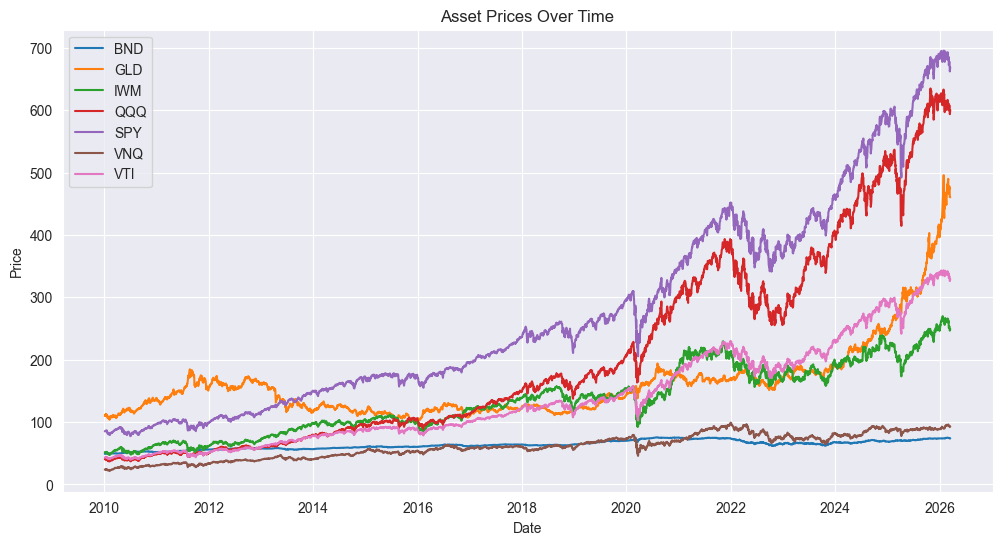

In [8]:
plt.figure(figsize=(12,6))

for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.title("Asset Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("../outputs/figures/asset_prices.png")

plt.show()

## Asset Prices over Time
The line plot of adjusted closing prices over time reveals the following trends:
- SPY, QQQ, VTI, and IWM show a general upward trend, reflecting the overall growth of the stock market during this period.
- BND exhibits a more stable price pattern, with less volatility compared to the equity ETFs, which is typical for bond ETFs. However it does not show a clear upward trend, which is expected given the low interest rate and low return environment for bonds during this period.
- GLD shows significant volatility, with no consistent upward or downward trend, until around 2024 when it starts to show a clear upward trend. This is consistent with gold's which can experience price spikes during periods of economic uncertainty.
- VNQ shows a consitent almost flat patter with slight upward trend, which is expected for a real estate ETF. Since real estate is not as volatile as stocks.
- Almost all assets show a significant drop in prices around early 2020, which corresponds to the market crash caused by the COVID-19 pandemic.

In [4]:
returns = data.pct_change().dropna()

returns.head()

,BND,GLD,IWM,QQQ,SPY,VNQ,VTI
Date,,,,,,,
2010-01-05,0.002924,-0.000911,-0.003439,0.000000,0.002647,-0.001122,0.003839
2010-01-06,-0.000380,0.016500,-0.000941,-0.006032,0.000704,-0.001798,0.001390
2010-01-07,-0.000761,-0.006188,0.007378,0.000650,0.004222,0.010806,0.004166
2010-01-08,0.001015,0.004963,0.005454,0.008231,0.003328,-0.007350,0.003285
2010-01-11,0.000381,0.013289,-0.004030,-0.004082,0.001397,0.005834,0.001378


## Returns Calculation
Returns are calculated using the formula:
```Return_t = (Price_t - Price_{t-1}) / Price_{t-1}
```
This formula computes the percentage change in price from one day to the next, providing a measure of the asset's performance over time. The resulting returns are used for further analysis, including correlation and distribution assessments.

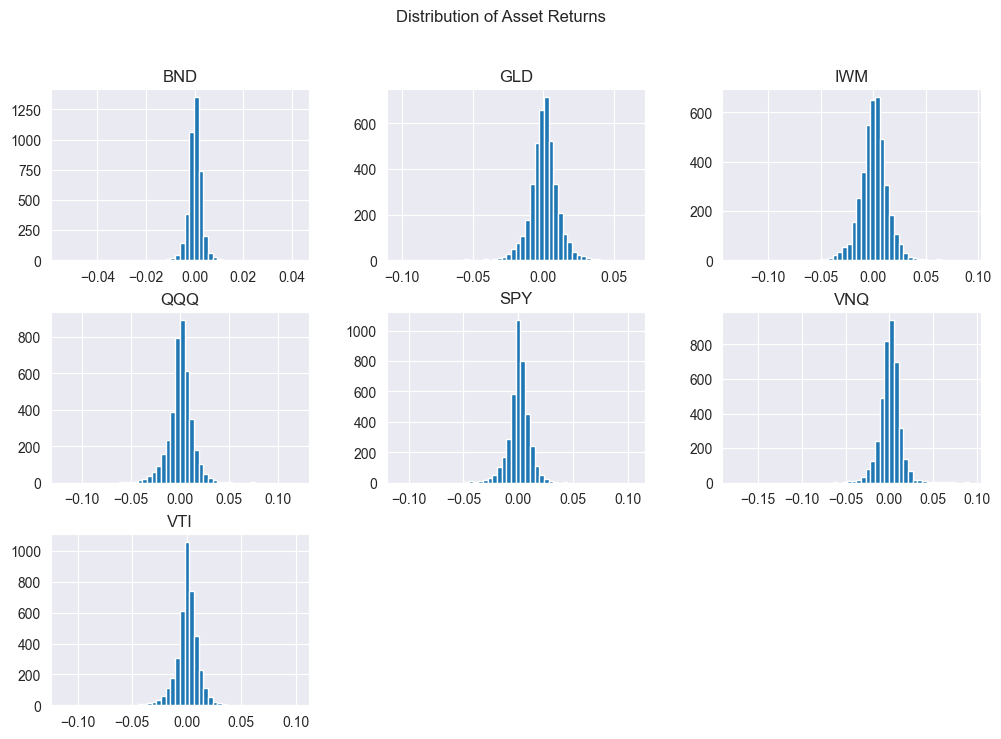

In [9]:
returns.hist(figsize=(12,8), bins=50)

plt.suptitle("Distribution of Asset Returns")
plt.savefig("../outputs/figures/return_distributions.png")
plt.show()

## Distribution of Asset Returns

The distribution of returns for each asset is visualized using histograms. 
Key observations include:
- SPY, QQQ, VTI, and IWM show a relatively normal distribution of returns, with a slight positive skew. This is typical for equity ETFs
- BDN shows a more symmetric distribution, which is expected for a bond ETF.
- GLD has a wider distribution with heavier tails, indicating higher volatility compared to the other assets.
- VNQ shows a distribution that is somewhat similar to the equity ETFs

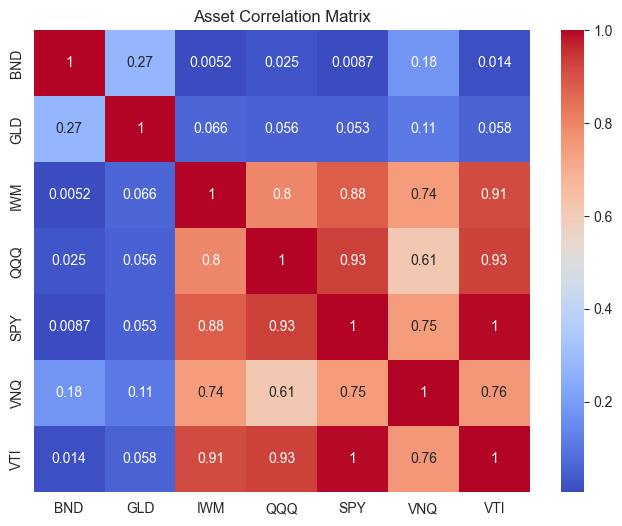

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")

plt.title("Asset Correlation Matrix")
plt.savefig("../outputs/figures/correlation_heatmap.png")
plt.show()

## Correlation Matrix

The correlation matrix reveals the relationships between the returns of the different assets. 

Key observations include:
- SPY, QQQ, VTI, and IWM show strong positive correlations, indicating they tend to move together as they represent different segments of the stock market.
- BND has a low correlation with the equity ETFs, suggesting it behaves differently. This makes sense since bonds are generally less volatile and often act inversely to stocks.
- GLD has a low to moderate correlation with the equity ETFs, which is expected as gold is often considered a "safer" investments.
- VNQ shows moderate correlations with the equity ETFs, which most likely means that real estate has some equity-like characteristics.

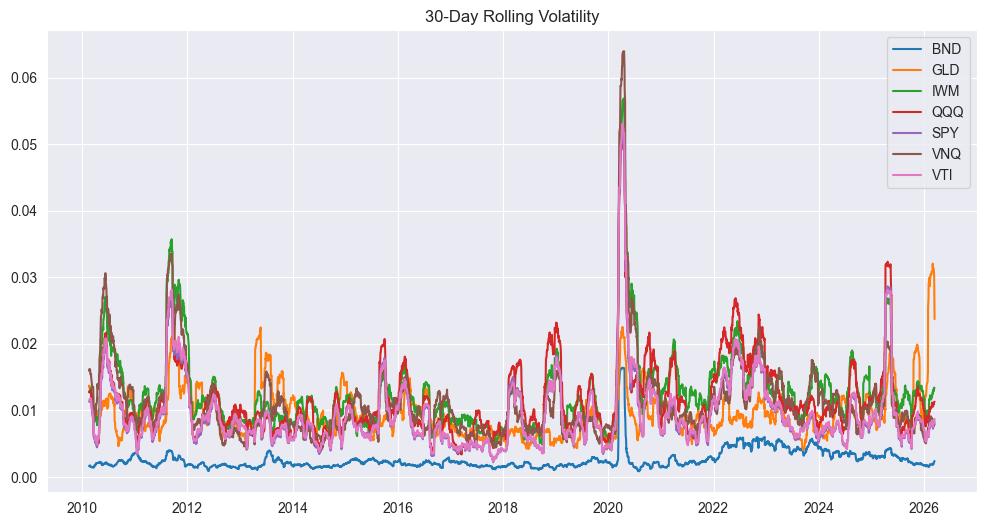

In [11]:
volatility = returns.rolling(30).std()

plt.figure(figsize=(12,6))

for col in volatility.columns:
    plt.plot(volatility.index, volatility[col], label=col)

plt.title("30-Day Rolling Volatility")
plt.legend()
plt.savefig("../outputs/figures/rolling_volatility.png")
plt.show()

###  30-Day Rolling Volatility

Volatility represents the variability of asset returns and is commonly used as a proxy for risk.

This is calculated as the standard deviation of daily returns over a rolling 30-day window. 

A rise in rolling volatility indicates increasing uncertainty and risk, while a decline suggests more stable market conditions.

The plot of rolling volatility for each asset reveals the following insights:
- SPY, QQQ, VTI, and IWM exhibit similar volatility patterns, with IWM generally showing higher volatility due to its focus on small-cap stocks.
- BND has significantly lower volatility compared to the equity ETFs, reflecting its bond holdings.
- GLD shows moderate volatility, influenced by gold price fluctuations.
- In 2020, there is a noticeable spike in volatility across all assets, corresponding to the market turmoil caused by the COVID-19 pandemic.


## Overall Summary
The exploratory analysis of the asset prices and returns reveals several key insights:
- Safe assets that are less volatile and have low correlation with the equity ETFs, such as BND and GLD, can provide diversification benefits in a portfolio.
- The equity ETFs (SPY, QQQ, VTI, IWM) show strong positive correlations with each other, indicating they tend to move together. This suggests that while they provide exposure to different segments of the stock market, they may not offer significant diversification benefits when combined in a portfolio.
- The real estate ETF (VNQ) shows moderate correlations with the equity ETFs, suggesting it has some equity-like characteristics but may still provide some diversification benefits.
- The significant drop in asset prices and spike in volatility around early 2020 highlights the importance of considering market downturns and tail risks when constructing a portfolio.